In [8]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [9]:
import h5py
import os
import re

folder = "results"   # your results folder
all_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("o04"):
        filepath = os.path.join(folder, filename)
        print(filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            all_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]



results/o04_i166_snr50_nspec10.h5
results/o04_i223_snr100nspec10.h5
results/o04_i6_snr10_nspec10.h5
results/o04_i0_snr50_nspec10.h5
results/o04_i41_snr10_nspec10.h5
results/o04_i0_snr100nspec10.h5
results/o04_i166_snr100nspec10.h5
results/o04_i223_snr50_nspec10.h5
results/o04_i166_snr10_nspec10.h5
results/o04_i6_snr50_nspec10.h5
results/o04_i41_snr50_nspec10.h5
results/o04_i0_snr10_nspec10.h5
results/o04_i41_snr100nspec10.h5
results/o04_i6_snr100nspec10.h5
results/o04_i223_snr10_nspec10.h5


In [10]:
np.median(wgrid[1:]/np.diff(wgrid))

600000.9999963294

In [11]:
s1 = int(0.01*inst_wgrid.shape[-1])
e1 = int(0.99*inst_wgrid.shape[-1])

start = np.searchsorted(wgrid, inst_wgrid[s1])
end = np.searchsorted(wgrid, inst_wgrid[e1])


In [12]:
spectrum_analysis['posterior_spectrum_samples'].shape

(1, 5, 1, 18752)

0.036277208271727486 0.008830110406533425
0.03646137639290794 0.014646374003545922
0.03712085509127524 0.01756447740577431
0.03847241543601591 0.018636857383975327
0.0368737210025061 0.02493953214893535


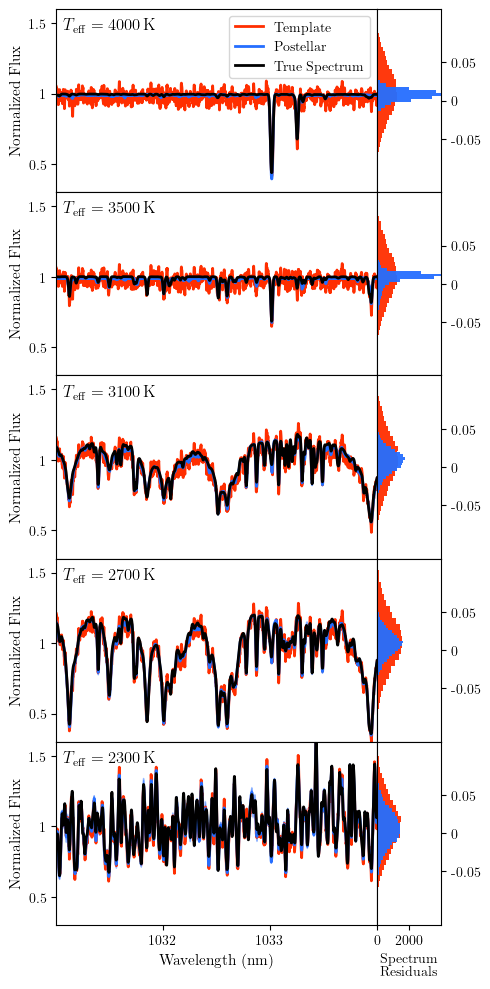

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
template_color = "#FF2E00"   # bright orange
postellar_color = "#256EFF"   # bright blue

cases = [(223,10,10),(166,10,10), (0,10,10), (41,10,10),(6,10,10)]
Teffs = [4000,3500,3100,2700,2300]

fig = plt.figure(figsize=(5, 2*len(cases)))

# Outer grid: 1 column, N rows, zero vertical padding
outer = gridspec.GridSpec(
    len(cases), 1,
    hspace=0.0       # <-- zero vertical space
)

shared_ax = None   # will store the first spectrum axis

for row, ((i, snr, nspec), Teff) in enumerate(zip(cases, Teffs)):

    # Get your data
    spectrum_analysis = all_data[(i, snr, nspec)]['spectrum']
    wavelength = wgrid[start:end]
    true_spec = spectrum_analysis['true_spectrum'][0,0,non_ones[0]:non_ones[-1]+1][start:end]
    template = spectrum_analysis['template'][start:end]
    post = spectrum_analysis['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]

    mean = np.percentile(post, 50, axis=(0,1))
    sigma_1 = np.percentile(post, [16, 84], axis=(0,1))
    sigma_2 = np.percentile(post, [2.5, 97.5], axis=(0,1))
    sigma_3 = np.percentile(post, [0.15, 99.85], axis=(0,1))

    temp_residuals = (true_spec - template)/true_spec
    diff_residuals = (true_spec - mean)/true_spec

    # Inner grid for this row: 1 spectrum + 1 histogram
    gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=outer[row],
        width_ratios=[5, 1],
        wspace=0
    )

    # -----------------------------
    # Spectrum axis (shared x)
    # -----------------------------
    if shared_ax is None:
        ax_spec = fig.add_subplot(gs[0,0])
        shared_ax = ax_spec   # store first spectrum axis
    else:
        ax_spec = fig.add_subplot(gs[0,0], sharex=shared_ax)
        # ax_spec.tick_params(labelbottom=False)  # hide x-labels except bottom

    # Plot spectra
    ax_spec.plot(wavelength, template, color=template_color, lw=2, label="Template")
    ax_spec.plot(wavelength, mean, color=postellar_color, lw=2, label="Postellar")
    ax_spec.plot(wavelength, true_spec, color='black', lw=2, label="True Spectrum")

    # Postella confidence interval
    ax_spec.fill_between(wavelength, sigma_3[0], sigma_3[1], color=postellar_color, alpha=0.2)
    ax_spec.fill_between(wavelength, sigma_2[0], sigma_2[1], color=postellar_color, alpha=0.3)
    ax_spec.fill_between(wavelength, sigma_1[0], sigma_1[1], color=postellar_color, alpha=0.4)

    ax_spec.set_ylabel("Normalized Flux", fontsize=11)
    text = f"$T_{{\\rm eff}} = {Teffs[row]}\\,\\mathrm{{K}}$"
    ax_spec.text(
    0.02, 0.95,          # x, y in axes fraction coordinates
    text,         # the label you want
    transform=ax_spec.transAxes,
    ha="left", va="top", # anchor the text
    fontsize=12          # whatever size you want
    )
    ax_spec.set_xlim(1031,1034)
    ax_spec.set_ylim(0.3,1.6)
    yticks = [0.5, 1, 1.5]
    ytick_labels = ["0.5", "1", "1.5"]

    ax_spec.set_yticks(yticks)
    ax_spec.set_yticklabels(ytick_labels)
    # ax_spec.set_title(f"SNR={snr}, nspec={nspec}, Teff={Teff}", fontsize=9)

    # -----------------------------
    # Histogram axis (not shared)
    # -----------------------------
    ax_hist = fig.add_subplot(gs[0,1])
    print(np.std(temp_residuals),np.std(diff_residuals))
    ax_hist.hist(temp_residuals, bins=50, orientation="horizontal", alpha=0.95, color=template_color)
    ax_hist.hist(diff_residuals, bins=50, orientation="horizontal", alpha=0.95, color=postellar_color)

    ax_hist.yaxis.tick_right()
    ax_hist.yaxis.set_label_position("right")

    yticks = [-0.05, 0, 0.05]
    ytick_labels = ["-0.05", "0", "0.05"]

    ax_hist.set_yticks(yticks)
    ax_hist.set_yticklabels(ytick_labels)
    ax_hist.set_xlim(0,4000)
    ax_hist.set_ylim(-0.12,0.12)

    if row==0:
        ax_spec.legend()

    if row!=4:
        ax_hist.tick_params(labelbottom=False)


    if row==4:
        ax_spec.set_xlabel("Wavelength (nm)", fontsize=11)
        xticks = [1032, 1033]#, 1033, 1034]
        xtick_labels = ["1032", "1033"]#, "1033", "1034"]

        ax_spec.set_xticks(xticks)
        ax_spec.set_xticklabels(xtick_labels)
        xticks = [0, 2000]
        xtick_labels = ["0", "2000"]

        ax_hist.set_xticks(xticks)
        ax_hist.set_xticklabels(xtick_labels)
        ax_hist.set_xlabel("Spectrum\nResiduals")

plt.savefig("phoenix_spectra_reconstruction.pdf",dpi=300)
plt.tight_layout()
plt.show()


In [14]:
1/0.008, 10*np.sqrt(10)

(125.0, 31.622776601683796)

(1, 18746) torch.Size([1, 1, 18746])
(1, 18746) torch.Size([1, 1, 18746])
(1, 18746) torch.Size([1, 1, 18746])
(1, 18746) torch.Size([1, 1, 18746])
(1, 18746) torch.Size([1, 1, 18746])


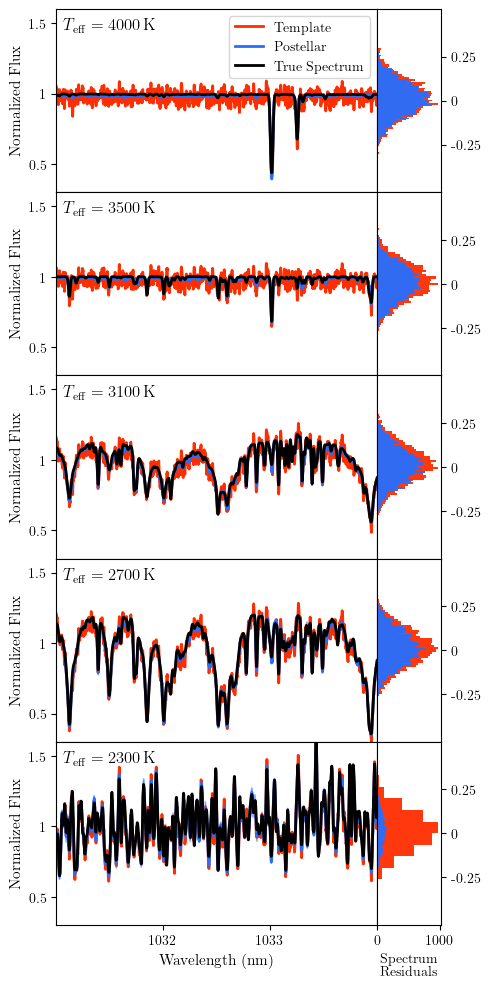

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
template_color = "#FF2E00"   # bright orange
postellar_color = "#256EFF"   # bright blue

cases = [(223,10,10),(166,10,10), (0,10,10), (41,10,10),(6,10,10)]
Teffs = [4000,3500,3100,2700,2300]

fig = plt.figure(figsize=(5, 2*len(cases)))

# Outer grid: 1 column, N rows, zero vertical padding
outer = gridspec.GridSpec(
    len(cases), 1,
    hspace=0.0       # <-- zero vertical space
)

shared_ax = None   # will store the first spectrum axis

for row, ((i, snr, nspec), Teff) in enumerate(zip(cases, Teffs)):

    # Get your data
    spectrum_analysis = all_data[(i, snr, nspec)]['spectrum']
    wavelength = wgrid[start:end]
    true_spec = spectrum_analysis['true_spectrum'][0,0,non_ones[0]:non_ones[-1]+1][start:end]
    template = spectrum_analysis['template'][start:end]
    post = spectrum_analysis['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]

    mean = np.percentile(post, 50, axis=(0,1))
    sigma_1 = np.percentile(post, [16, 84], axis=(0,1))
    sigma_2 = np.percentile(post, [2.5, 97.5], axis=(0,1))
    sigma_3 = np.percentile(post, [0.15, 99.85], axis=(0,1))

    temp_residuals = (true_spec - template)/true_spec
    diff_residuals = (true_spec - mean)/true_spec


    # Data residuals 
    true_specf = spectrum_analysis['true_spectrum'][0,0,non_ones[0]:non_ones[-1]+1]
    templatef = spectrum_analysis['template']
    meanf = spectrum_analysis['posterior_spectrum_samples'][:,0,0,non_ones[0]:non_ones[-1]+1]
    wavelengthf = wgrid




    a = torch.tensor(true_specf).unsqueeze(0).unsqueeze(0)
    b = torch.tensor(wavelengthf)
    c = torch.tensor(inst_wgrid)
    data_forward = (forward_model(a,b,c,torch.tensor([[0]]),torch.tensor([[0]])))[0,0]+(torch.normal(0,1/snr,inst_wgrid.shape))
    d = torch.tensor(templatef).unsqueeze(0).unsqueeze(0)
    temp_forward = forward_model(d,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]
    print(meanf.shape, d.shape)
    e = torch.tensor(meanf).unsqueeze(0)
    post_forward = forward_model(e,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]
    temp_residuals = data_forward - temp_forward
    diff_residuals = data_forward - post_forward

    # Inner grid for this row: 1 spectrum + 1 histogram
    gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=outer[row],
        width_ratios=[5, 1],
        wspace=0
    )

    # -----------------------------
    # Spectrum axis (shared x)
    # -----------------------------
    if shared_ax is None:
        ax_spec = fig.add_subplot(gs[0,0])
        shared_ax = ax_spec   # store first spectrum axis
    else:
        ax_spec = fig.add_subplot(gs[0,0], sharex=shared_ax)
        # ax_spec.tick_params(labelbottom=False)  # hide x-labels except bottom

    # Plot spectra
    ax_spec.plot(wavelength, template, color=template_color, lw=2, label="Template")
    ax_spec.plot(wavelength, mean, color=postellar_color, lw=2, label="Postellar")
    ax_spec.plot(wavelength, true_spec, color='black', lw=2, label="True Spectrum")

    # Postella confidence interval
    ax_spec.fill_between(wavelength, sigma_3[0], sigma_3[1], color=postellar_color, alpha=0.2)
    ax_spec.fill_between(wavelength, sigma_2[0], sigma_2[1], color=postellar_color, alpha=0.3)
    ax_spec.fill_between(wavelength, sigma_1[0], sigma_1[1], color=postellar_color, alpha=0.4)

    ax_spec.set_ylabel("Normalized Flux", fontsize=11)
    text = f"$T_{{\\rm eff}} = {Teffs[row]}\\,\\mathrm{{K}}$"
    ax_spec.text(
    0.02, 0.95,          # x, y in axes fraction coordinates
    text,         # the label you want
    transform=ax_spec.transAxes,
    ha="left", va="top", # anchor the text
    fontsize=12          # whatever size you want
    )
    ax_spec.set_xlim(1031,1034)
    ax_spec.set_ylim(0.3,1.6)
    yticks = [0.5, 1, 1.5]
    ytick_labels = ["0.5", "1", "1.5"]

    ax_spec.set_yticks(yticks)
    ax_spec.set_yticklabels(ytick_labels)
    # ax_spec.set_title(f"SNR={snr}, nspec={nspec}, Teff={Teff}", fontsize=9)

    # -----------------------------
    # Histogram axis (not shared)
    # -----------------------------
    ax_hist = fig.add_subplot(gs[0,1])
    ax_hist.hist(temp_residuals, bins=80, orientation="horizontal", alpha=0.95, color=template_color)
    ax_hist.hist(diff_residuals, bins=80, orientation="horizontal", alpha=0.95, color=postellar_color)

    ax_hist.yaxis.tick_right()
    ax_hist.yaxis.set_label_position("right")

    yticks = [-0.25, 0, 0.25]
    ytick_labels = ["-0.25", "0", "0.25"]

    ax_hist.set_yticks(yticks)
    ax_hist.set_yticklabels(ytick_labels)
    # ax_hist.set_xlim(0,2000)
    ax_hist.set_ylim(-0.52,0.52)

    if row==0:
        ax_spec.legend()

    if row!=4:
        ax_hist.tick_params(labelbottom=False)


    if row==4:
        ax_spec.set_xlabel("Wavelength (nm)", fontsize=11)
        xticks = [1032, 1033]#, 1033, 1034]
        xtick_labels = ["1032", "1033"]#, "1033", "1034"]

        ax_spec.set_xticks(xticks)
        ax_spec.set_xticklabels(xtick_labels)
        # xticks = [0, 2000]
        # xtick_labels = ["0", "2000"]

        # ax_hist.set_xticks(xticks)
        # ax_hist.set_xticklabels(xtick_labels)
        ax_hist.set_xlabel("Spectrum\nResiduals")


plt.tight_layout()
plt.show()


In [16]:
diff_residuals.shape

torch.Size([4088])

In [17]:
wavelength

array([1007.309368  , 1007.31104685, 1007.3127257 , ..., 1038.63196107,
       1038.63369213, 1038.63542318])

In [18]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# # --- Pick which cases to compare (just change these tuples) ---
# cases = [(6,10, 10), (0, 10, 10), (166,10,10)]   # example: two SNR values, same nspec=25
# Teffs= [2300,3100,3500]
# fig, axes = plt.subplots(len(cases), 1, figsize=(12, 4*len(cases)))

# if len(cases) == 1:
#     axes = [axes]  # make iterable if only one case

# j = 0
# for ax_row, (i, snr, nspec) in zip(axes, cases):
#     spectrum_analysis = all_data[(i, snr, nspec)]['spectrum']

#     wavelength = wgrid[start:end]
#     wavelengthf = wgrid
#     true_spec = spectrum_analysis['true_spectrum'][0,0,non_ones[0]:non_ones[-1]+1][start:end]
#     true_specf = spectrum_analysis['true_spectrum'][0,0,non_ones[0]:non_ones[-1]+1]
#     template = spectrum_analysis['template'][start:end]
#     templatef = spectrum_analysis['template']
#     post = spectrum_analysis['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]
#     # mean = spectrum_analysis['posterior_spectrum_samples'][:,0,0,non_ones[0]:non_ones[-1]+1][start:end]
#     meanf = spectrum_analysis['posterior_spectrum_samples'][:,0,0,non_ones[0]:non_ones[-1]+1]
#     mean = np.percentile(post, [50], axis=[0,1])[0] 
#     sigma_1 = np.percentile(post, [16, 84], axis=[0,1])
#     sigma_2 = np.percentile(post, [2.5, 97.5], axis=[0,1])
#     sigma_3 = np.percentile(post, [0.15, 99.85], axis=[0,1])

#     temp_residuals = true_spec - template
#     diff_residuals = true_spec - mean

#     ## Data residuals 
#     # a = torch.tensor(true_specf).unsqueeze(0).unsqueeze(0)
#     # b = torch.tensor(wavelengthf)
#     # c = torch.tensor(inst_wgrid)
#     # data_forward = (forward_model(a,b,c,torch.tensor([[0]]),torch.tensor([[0]])))[0,0]+(torch.normal(0,1/snr,inst_wgrid.shape))
#     # d = torch.tensor(templatef).unsqueeze(0).unsqueeze(0)
#     # temp_forward = forward_model(d,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]

#     # e = torch.tensor(meanf).unsqueeze(0).unsqueeze(0)
#     # post_forward = forward_model(e,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]


#     # ---- Layout with 2x2 GridSpec ----
#     gs = gridspec.GridSpecFromSubplotSpec(
#         2, 1, width_ratios=[5,1], height_ratios=[1,1],
#         wspace=0.05, hspace=0.25, subplot_spec=ax_row.get_subplotspec()
#     )

#     # --- Top left: full spectrum ---
#     ax_full = fig.add_subplot(gs[0,0])
#     ax_full.plot(wavelength, template, label="Template", color='red')
#     ax_full.plot(wavelength, mean, label="Mean Posterior", color='blue')
#     ax_full.plot(wavelength, true_spec, label="True Spectrum", color='black', linewidth=1.5)
#     ax_full.fill_between(wavelength, sigma_3[0], sigma_3[1], color='blue', alpha=0.2)
#     ax_full.fill_between(wavelength, sigma_2[0], sigma_2[1], color='blue', alpha=0.3)
#     ax_full.fill_between(wavelength, sigma_1[0], sigma_1[1], color='blue', alpha=0.4)
#     ax_full.legend(fontsize=8)
#     ax_full.set_ylabel("Normalized Flux")
#     ax_full.set_title(f"SNR={snr}, nspec={nspec}, Teff={Teffs[j]}")
#     ax_full.set_xlim(1520,1525)
#     # ax_full.set_xlim(1511,1559)
#     # ax_full.set_xlim(1025,1027)
#     # ax_full.set_ylim(0.4,1.3)

#     # # --- Bottom left: zoom-in spectrum subset via xlim ---
#     # ax_zoom = fig.add_subplot(gs[1,0])
#     # ax_zoom.fill_between(inst_wgrid, -1/snr, 1/snr, color='grey', alpha=0.75)
#     # ax_zoom.scatter(inst_wgrid[s1:e1], (data_forward-temp_forward)[s1:e1], color='red',alpha=0.3)
#     # ax_zoom.scatter(inst_wgrid[s1:e1], (data_forward-post_forward)[s1:e1], color='blue',alpha=0.3)

#     # ax_zoom.plot(wavelength, true_spec, color='black', linewidth=1.5)
#     # ax_zoom.fill_between(wavelength, sigma_3[0], sigma_3[1], color='blue', alpha=0.2)
#     # ax_zoom.fill_between(wavelength, sigma_2[0], sigma_2[1], color='blue', alpha=0.3)
#     # # ax_zoom.fill_between(wavelength, sigma_1[0], sigma_1[1], color='blue', alpha=0.4)
#     # ax_zoom.set_xlabel("Wavelength (nm)")
#     # ax_zoom.set_ylabel("Data Residuals")
#     # ax_zoom.set_xlim(1520,1525)
#     # # ax_zoom.set_xlim(1511,1559)
#     # # ax_zoom.set_xlim(1025,1027)
#     # # ax_zoom.set_xlim(1299,1301)

#     # ax_zoom.set_ylim(-5/snr,5/snr)  # zoom region

#     # --- Right side: residual histograms (span both rows) ---
#     ax_hist = fig.add_subplot(gs[:,1])  # spans rows 0 and 1
#     ax_hist.hist(temp_residuals, bins=20, orientation="horizontal", color="red", alpha=0.6, label="Template Residuals")
#     ax_hist.hist(diff_residuals, bins=20, orientation="horizontal", color="blue", alpha=0.6, label="Prior Informed Residuals")
#     ax_hist.set_ylim(-2/snr,2/snr)
#     ax_hist.yaxis.tick_right()
#     ax_hist.yaxis.set_label_position("right")
#     ax_hist.set_ylabel("Spectrum Residuals")
#     ax_hist.legend(fontsize=8)
#     print(np.sqrt(np.mean(diff_residuals**2)),np.sqrt(np.mean(temp_residuals**2)))
#     print(np.sqrt(np.mean(diff_residuals**2)))
#     j+=1


#     ax_row.tick_params(labelbottom=False,bottom=False,left=False,labelleft=False)
#     for spine in ax_row.spines.values():
#         spine.set_visible(False)
# plt.tight_layout()
# plt.show()


In [19]:
# wavelength

In [20]:
import numpy as np

final_results = {}

for (i, snr, nspec), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_rmse": [],
        "template_rmse": [],
        "mala_rmse": [],
        "prior_rmse": [],
        "intrinsic_unc": [],
        "template_unc": [],
        "mala_unc": [],
        "prior_unc": [],
        "intrinsic_z_mean": [],
        "intrinsic_z_std": [],
        "template_z_mean": [],
        "template_z_std": [],
        "mala_z_mean": [],
        "mala_z_std": [],
        "prior_z_mean": [],
        "prior_z_std": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        prior = group["prior_rv"][()]
        mala = group["mala_samples"][()]
        # Point estimates for mala
        mala_mean = mala.mean(axis=0).mean(axis=0)#[0]
        mala_std = mala.std(axis=0).mean(axis=0)#[0]

        # --- RMSE ---
        results["intrinsic_rmse"].append(np.sqrt(np.mean((intrinsic - true) ** 2)))
        results["prior_rmse"].append(np.sqrt(np.mean((prior - true) ** 2)))
        results["template_rmse"].append(np.sqrt(np.mean((template - true) ** 2)))
        results["mala_rmse"].append(np.sqrt(np.mean((mala_mean - true) ** 2)))

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        prior_unc = group["prior_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        prior_z = (prior - true) / prior_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        

        results["intrinsic_z_mean"].append(intrinsic_z.mean())
        results["intrinsic_z_std"].append(intrinsic_z.std())
        results["intrinsic_unc"].append(intrinsic_unc.mean())
        results["template_unc"].append(template_unc.mean())
        results["prior_unc"].append(prior_unc.mean())
        results["mala_unc"].append(mala_std.mean())
        results["template_z_mean"].append(template_z.mean())
        results["template_z_std"].append(template_z.std())
        results["mala_z_mean"].append(mala_z.mean())
        results["mala_z_std"].append(mala_z.std())
        results["prior_z_mean"].append(prior_z.mean())
        results["prior_z_std"].append(prior_z.std())

    # --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: np.mean(v) for k, v in results.items()}


In [21]:
import pandas as pd

# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec"])
df_rmse = df_results.reset_index()

# df_results[(df_results['i']==6)&(df_results['nspec']==10)]
df_rmse

,i,snr,nspec,intrinsic_rmse,template_rmse,mala_rmse,prior_rmse,intrinsic_unc,template_unc,mala_unc,prior_unc,intrinsic_z_mean,intrinsic_z_std,template_z_mean,template_z_std,mala_z_mean,mala_z_std,prior_z_mean,prior_z_std
0,166,50,10,31.353475,57.636374,33.105520,32.847196,31.618263,30.823494,31.361900,31.557458,0.009113,0.990438,-0.338723,1.893424,-0.152476,1.049680,-0.150211,1.028852
1,223,100,10,18.954587,26.994405,23.706937,23.805121,19.591410,19.620500,19.477868,19.556667,0.020788,0.965651,0.328057,1.353189,0.597179,1.069431,0.595174,1.064750
2,6,10,10,25.590846,43.073015,26.658552,26.660955,24.761557,25.162081,25.237526,25.349453,0.051136,1.025536,-0.668663,1.608991,-0.132180,1.046212,-0.131496,1.036359
3,0,50,10,13.347746,17.515150,13.880141,13.786955,14.420467,14.548032,14.433134,14.508775,-0.001063,0.924506,-0.414381,1.133347,-0.143676,0.952486,-0.142019,0.937737
4,41,10,10,44.820679,101.076977,47.108647,47.096046,45.087904,36.632732,45.889220,46.128227,-0.002292,0.991334,-0.705636,2.780561,-0.195336,1.006880,-0.194423,0.999691
5,0,100,10,6.665708,7.878198,6.928802,6.880515,7.213072,7.274800,7.186446,7.228495,-0.000278,0.923013,-0.437229,0.989787,-0.173106,0.947245,-0.172430,0.934576
6,166,100,10,15.647898,20.800783,16.346308,16.185337,15.816386,15.923177,15.652315,15.742734,0.009276,0.988404,-0.363197,1.261739,0.107490,1.041298,0.109741,1.022209
7,223,50,10,37.941008,81.462285,42.539891,41.904247,39.172621,34.892801,38.923377,39.217665,0.020224,0.966673,0.496850,2.351701,0.348358,1.040431,0.341748,1.012868
8,166,10,10,161.974766,352.564544,191.842312,192.755137,156.387057,45.171306,188.150960,188.223041,0.007619,1.032719,-0.178595,8.205450,-0.110049,1.012857,-0.116617,1.023604
9,6,50,10,5.002128,6.574961,5.193453,5.181220,5.002699,5.074086,4.981386,5.021254,0.056279,0.991562,-0.718959,1.074080,-0.235832,1.015693,-0.230519,0.999422


In [22]:
# import matplotlib.pyplot as plt
# Teffs= [2300,2700,3100,3500,4000]
# # Get all unique nspec values
# nspec_values = [10, 50]

# fig, axes = plt.subplots(len([1,0]), 2, figsize=(15, 5*len(nspec_values)), sharex=True)

# # if len(nspec_values) == 1:
# #     axes = [axes]  # make iterable if only one nspec

# for i,s in enumerate([6,41, 0,166, 223]):
#     for_one_spec = df_results[df_results['i']==s]
#     for j,nspec in enumerate(nspec_values):
#         print(nspec)
#         group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")
#         print(group.columns)
#         axes[j,i].errorbar(group["snr"]-2, group["template_z_mean"], group["template_z_std"],marker='o', ls="",capsize=4,c="r",label="Template")
#         axes[j,i].errorbar(group["snr"]+2, group["mala_z_mean"], group["mala_z_std"], marker='o',c="b", ls="",capsize=4,label="Prior Informed")
#         axes[j,i].errorbar(group["snr"], group["intrinsic_z_mean"], group["intrinsic_z_std"],marker='o', ls="",c="k",capsize=4,label="Intrinsic")

#         axes[j,i].hlines(0,0,210,color="k",lw=3)
#         axes[j,i].fill_between(np.linspace(0,210,10),-1,1,color="k",alpha=0.1)
#         axes[j,i].set_ylabel("Zscores")
#         axes[j,i].set_xlabel("SNR")
#         axes[j,i].set_title(f"Teff={Teffs[i]},nspec = {nspec}")
#         # axes[j,i].grid(True, alpha=0.3)
#         # axes[j,i].set_yscale("log")
#         # axes[j,i].set_xscale("log")
#         axes[j,i].legend()
#         axes[j,i].set_xlim(0,210)


# # axes[-1].set_xlabel("SNR")
# plt.tight_layout()
# plt.show()


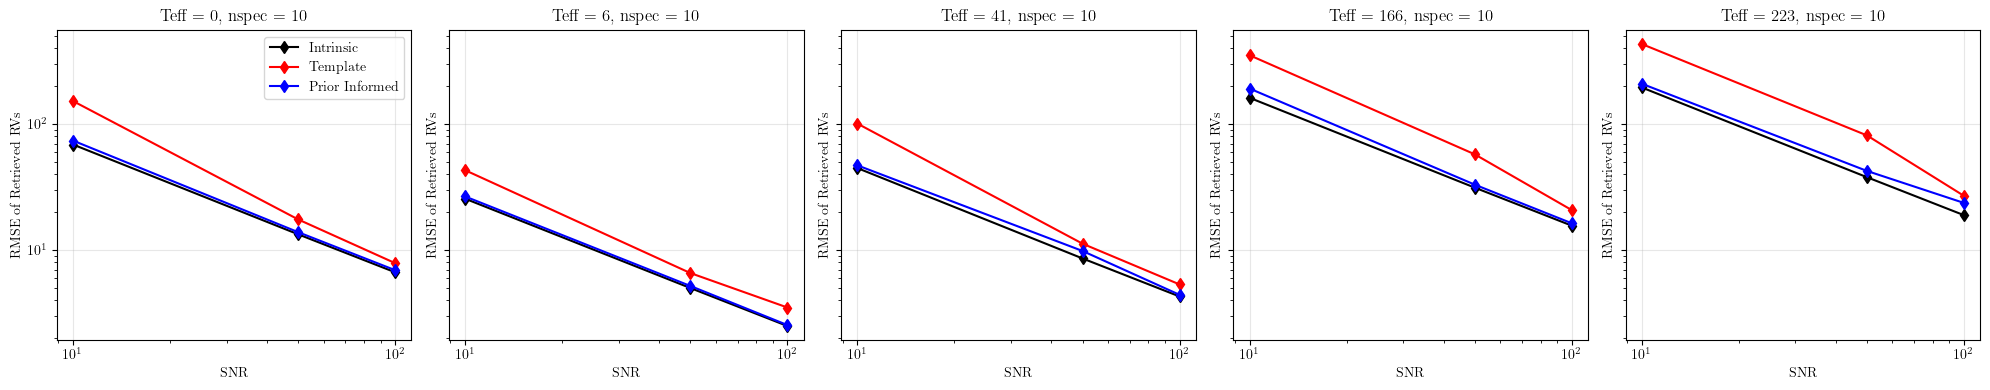

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# unique "i" values
i_values = sorted(df_rmse["i"].unique())

# get unique nspec values across all i’s
all_nspec_values = sorted(df_rmse["nspec"].unique())

# create subplots with flexible size
nrows = len(all_nspec_values)
ncols = len(i_values)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)

# Make sure axes is always 2D array (even if 1 row or 1 col)
axes = np.atleast_2d(axes)

for col, i_val in enumerate(i_values):
    for_one_spec = df_rmse[df_rmse['i'] == i_val]
    nspec_values = sorted(for_one_spec["nspec"].unique())
    
    for row, nspec in enumerate(nspec_values):
        group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")

        ax = axes[row, col]
        ax.plot(group["snr"], group["intrinsic_rmse"], marker="d", c="k", label="Intrinsic")
        ax.plot(group["snr"], group["template_rmse"], marker="d", c="r", label="Template")
        ax.plot(group["snr"], group["mala_rmse"], marker="d", c="b", label="Prior Informed")

        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("SNR")
        ax.set_ylabel("RMSE of Retrieved RVs")

        teff_label = Teffs[col] if col < len(Teffs) else "?"
        ax.set_title(f"Teff = {i_val}, nspec = {nspec}")

        if row == 0 and col == 0:
            ax.legend()

plt.tight_layout()
plt.show()


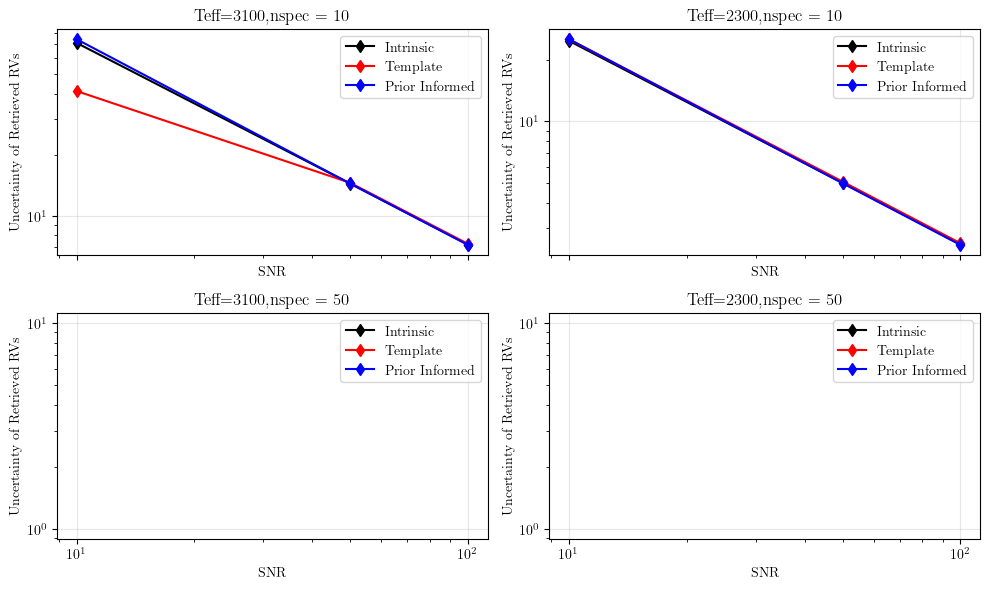

In [24]:
import matplotlib.pyplot as plt
Teffs= [3100,2300]
nspec_values = [10,50]
fig, axes = plt.subplots(len(nspec_values), 2, figsize=(10, 3*len(nspec_values)), sharex=True)

# if len(nspec_values) == 1:
#     axes = [axes]  # make iterable if only one nspec

for i,s in enumerate([0,6]):
    for_one_spec = df_rmse[df_rmse['i']==s]
    nspec_values = [10,50]#sorted(for_one_spec["nspec"].unique())
    for j,nspec in enumerate(nspec_values):
        group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")
        
        axes[j,i].plot(group["snr"], group["intrinsic_unc"], marker="d", c="k",label="Intrinsic")
        axes[j,i].plot(group["snr"], group["template_unc"], marker="d", c="r",label="Template")
        axes[j,i].plot(group["snr"], group["mala_unc"], marker="d",c="b", label="Prior Informed")
        print()
        axes[j,i].set_ylabel("Uncertainty of Retrieved RVs")
        axes[j,i].set_title(f"Teff={Teffs[i]},nspec = {nspec}")
        axes[j,i].grid(True, alpha=0.3)
        axes[j,i].set_yscale("log")
        axes[j,i].set_xscale("log")
        axes[j,i].legend()
        axes[j,i].set_xlabel("SNR")


# axes[-1].set_xlabel("SNR")
plt.tight_layout()
plt.show()

In [25]:
import numpy as np

final_results = {}

for (i, snr, nspec), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_z": [],
        "template_z": [],
        "mala_z": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        mala = group["mala_samples"][()]   # shape: (n_samples,)
        # Point estimates for mala
        mala_mean = mala.mean(axis=(0,1))#[0]
        mala_std = mala.std(axis=(0,1))#.mean(axis=0)#[0]

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        

        results["intrinsic_z"].append(intrinsic_z)
        results["template_z"].append(template_z)
        results["mala_z"].append(mala_z)

    # --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: v for k, v in results.items()}


In [26]:
import pandas as pd

# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec"])
df_results = df_results.reset_index()

# df_results[(df_results['i']==6)&(df_results['nspec']==10)]
# df_results

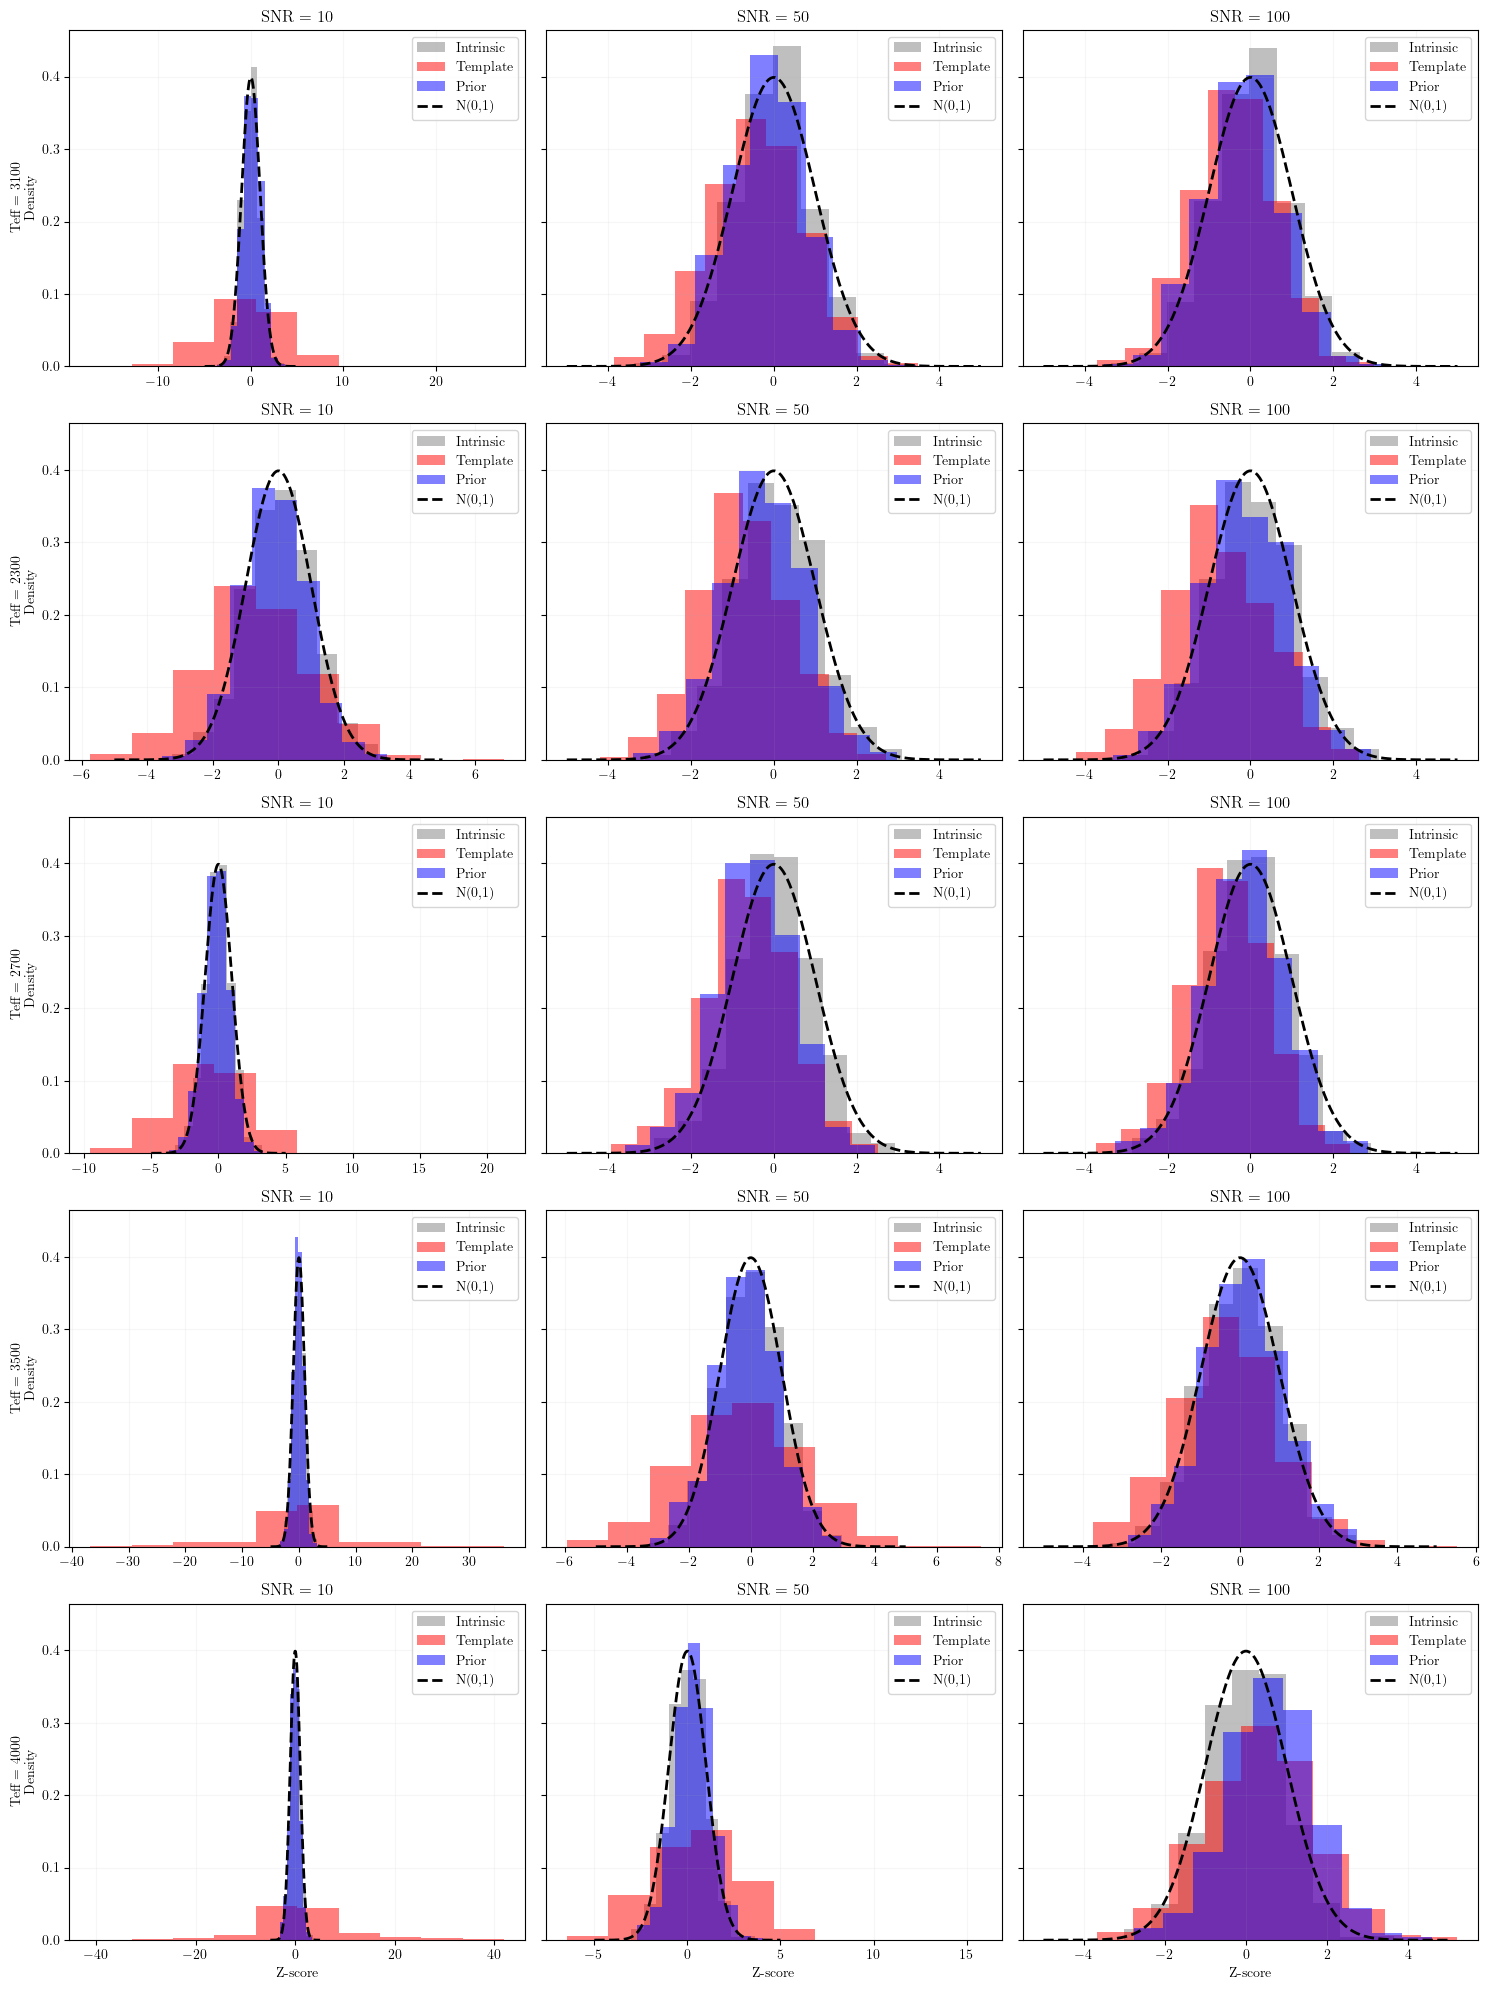

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
i_values = [0, 6, 41,166,223]                  # multiple i values
Teffs= [3100,2300,2700, 3500, 4000]
snr_values = [10, 50, 100]            # three SNR values
columns_to_plot = ['intrinsic_z', 'template_z', 'mala_z']
labels = ['Intrinsic', 'Template', 'Prior']
colors = ['grey', 'red', 'blue']

# Create subplots: rows = i_values, cols = SNRs
fig, axes = plt.subplots(len(i_values), len(snr_values), figsize=(5*len(snr_values), 4*len(i_values)), sharey=True)

for row_idx, i_value in enumerate(i_values):
    # Filter for specific i
    df_i = df_results[df_results['i'] == i_value]
    
    for col_idx, snr in enumerate(snr_values):
        ax = axes[row_idx, col_idx] if len(i_values) > 1 else axes[col_idx]
        df_snr = df_i[(df_i['snr'] == snr) & (df_i['nspec'] == 10)]
        
        # Overplot histogram for each column
        for j, col in enumerate(columns_to_plot):
            values = df_snr[col].values
            ax.hist(values, bins=10, alpha=0.5, density=True, label=labels[j], color=colors[j])
        
        # Overplot standard normal
        x = np.linspace(-5, 5, 200)
        ax.plot(x, norm.pdf(x), 'k--', label='N(0,1)', lw=2)
        
        # Labels & grid
        if row_idx == len(i_values)-1:
            ax.set_xlabel("Z-score")
        if col_idx == 0:
            ax.set_ylabel(f"Teff = {Teffs[row_idx]}\nDensity")
        ax.set_title(f"SNR = {snr}")
        ax.legend()
        ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()


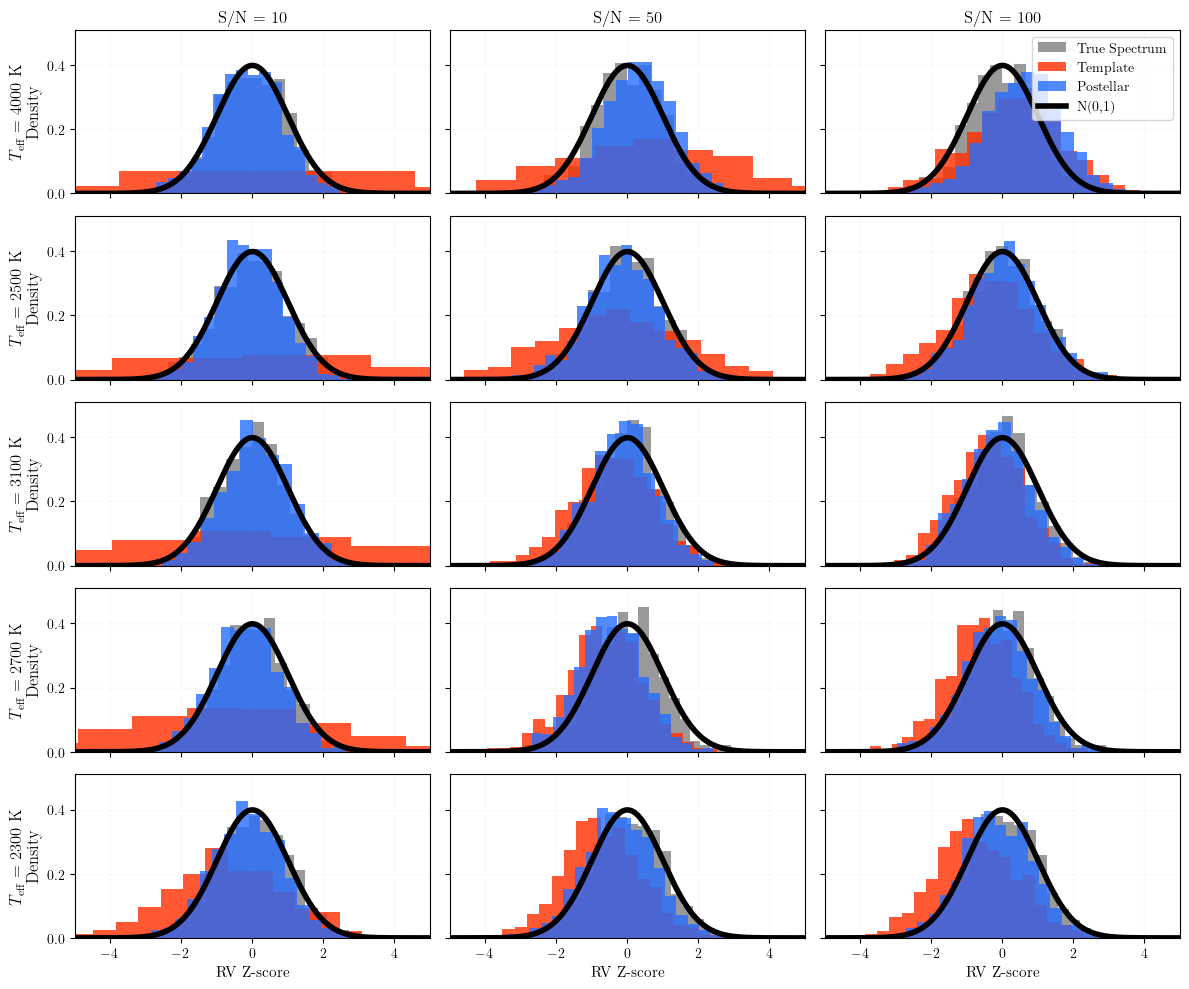

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
# Parameters
i_values = [223,166,0,41,6]#[6, 41,0, 166, 223]
Teffs = [4000,2500,3100,2700,2300]#[2300,2700,3100, 3500, 4000]
snr_values = [10, 50, 100]

columns_to_plot = ['intrinsic_z', 'template_z', 'mala_z']
# columns_to_plot = ['template_z', 'mala_z','intrinsic_z', ]
labels = ['True Spectrum', 'Template', 'Postellar']
# labels = ['Template', 'Postellar','True Spectrum']
colors = ['grey', template_color, postellar_color] 
# colors = [template_color, postellar_color,'darkgrey']   # warm template + cool postella green

Nrows = len(i_values)
Ncols = len(snr_values)    # +1 for your extra column

fig, axes = plt.subplots(
    Nrows, Ncols,
    figsize=(4*Ncols, 2*Nrows),
    sharex=True,sharey=True
)
plt.subplots_adjust(hspace=0, wspace=0)
if Nrows == 1:
    axes = axes[np.newaxis, :]

x = np.linspace(-5, 5, 400)   # domain for curves

for row_idx, i_value in enumerate(i_values):

    df_i = df_results[df_results['i'] == i_value]

    for col_idx in range(Ncols):

        ax = axes[row_idx, col_idx]

        # -------------------------------------------
        # FIRST THREE COLUMNS — Gaussian fits
        # -------------------------------------------
        if col_idx < 3:
            snr = snr_values[col_idx]
            df_snr = df_i[(df_i['snr'] == snr) & (df_i['nspec'] == 10)]

            # Loop through Intrinsic / Template / Prior
            for j, col in enumerate(columns_to_plot):
                values = df_snr[col].values
                values = np.array(values).flatten()
                
                if len(values) > 1:
                    mu = values.mean()
                    sigma = values.std()
                else:
                    mu = 0
                    sigma = 1   # fallback to avoid errors

                # gaussian = norm.pdf(x, loc=mu, scale=sigma)
                # ax.fill_between(x, 0,gaussian, color=colors[j], label=labels[j])
                ax.hist(values,bins=20,color=colors[j],label=labels[j],density=True,alpha=0.8)

            # Standard normal curve
            ax.plot(x, norm.pdf(x), c='k',ls="-" ,lw=4, label="N(0,1)")

            # Titles / labels
            if row_idx == 0:
                ax.set_title(f"S/N = {snr}", fontsize=12)

            if col_idx == 0:
                ax.set_ylabel(f"$T_{{\\rm eff}}$ = {Teffs[row_idx]} K\nDensity",
                               fontsize=12)
            ax.set_ylim(0,0.51)
            ax.set_xlim(-5,5)

            # Bottom row has x-labels
            if row_idx == Nrows - 1:
                ax.set_xlabel("RV Z-score", fontsize=11)

            ax.grid(alpha=0.05)

            # Add legend only once (top-left panel)
            if row_idx == 0 and col_idx == 2:
                ax.legend(loc="upper right")
        # -------------------------------------------
        # FOURTH COLUMN — your extra diagnostic plot
        # -------------------------------------------
        else:
            group = df_rmse[(df_rmse['i'] == i_value)]
            group = group.sort_values("snr")
            ax.plot(group["snr"], group["intrinsic_rmse"], marker="d", lw=3,ms=10,c="k", label="Intrinsic")
            ax.plot(group["snr"], group["template_rmse"], marker="d",lw=3, ms=10,c=template_color, label="Template")
            ax.plot(group["snr"], group["mala_rmse"], marker="d", lw=3,ms=10,c=postellar_color, label="Postellar")
            if row_idx == 0:
                ax.set_title("Accuracy", fontsize=12)
            ax.yaxis.tick_right()          # Move tick marks + tick labels to the right
            
            ax.set_ylabel("RMSE", fontsize=11)
            ax.yaxis.set_label_position("right")
            ax.set_yscale("log")
            ax.set_xscale("log")
            
            ax.grid(alpha=0.15)
            if row_idx == Nrows - 1:
                ax.set_xlabel("S/N", fontsize=11)
            # Remove x tick labels unless bottom row
            if row_idx != Nrows - 1:
                ax.set_xticklabels([])
                ax.set_xticks([])


        # Remove x tick labels unless bottom row
        # if row_idx != Nrows - 1:
        #     ax.set_xticklabels([])
        #     ax.set_xticks([])

        # Remove y tick labels unless first column (col_idx == 0)
        # BUT do not remove for the 4th column (col_idx == 3) because those live on the right side
        # if col_idx != 0 and col_idx != 3:
        #     ax.set_yticklabels([])
        #     ax.set_yticks([])
plt.savefig("phoenix_rvs.pdf",dpi=300)
plt.tight_layout()
plt.show()
